Seleccione el archivo de datos:


Saving datos_machine_learning_seccion_4.xlsx to datos_machine_learning_seccion_4 (17).xlsx
Archivo seleccionado: datos_machine_learning_seccion_4 (17).xlsx
Primeras 5 filas:
   id_vuelo  distancia_km  hora_salida  clima  trafico_aeropuerto  retrasado
0         1           250            5      2                   5          1
1         2           450           12      0                   2          0
2         3          1600            7      2                   7          1
3         4           180            5      0                   4          0
4         5           450           21      2                   1          0

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id_vuelo            80 non-null     int64
 1   distancia_km        80 non-null     int64
 2   hora_salida         80 non-null     int64
 

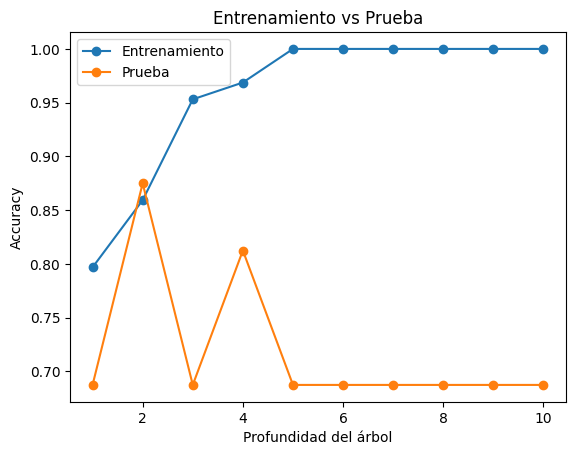

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from google.colab import files

print("Seleccione el archivo de datos:")
subido = files.upload()

nombre_archivo = list(subido.keys())[0]

print("Archivo seleccionado:", nombre_archivo)

df = pd.read_excel(nombre_archivo, sheet_name="Vuelos")

print("Primeras 5 filas:")
print(df.head())

print("\nInformación del dataset:")
print(df.info())

print("\nCantidad de vuelos retrasados:")
print(df["retrasado"].value_counts())

X = df[[
    "distancia_km",
    "hora_salida",
    "clima",
    "trafico_aeropuerto"
]]

y = df["retrasado"]

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Datos de entrenamiento:", len(X_entrenamiento))
print("Datos de prueba:", len(X_prueba))

#------------------------Regresión logística--------------------------------------
modelo_logistico = LogisticRegression()

modelo_logistico.fit(X_entrenamiento, y_entrenamiento)

predicciones_logistico = modelo_logistico.predict(X_prueba)

accuracy_logistico = accuracy_score(
    y_prueba,
    predicciones_logistico
)

print("Exactitud Regresión Logística:", accuracy_logistico*100)
#------------------------Árbol de decisión--------------------------------------
modelo_arbol = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

modelo_arbol.fit(X_entrenamiento, y_entrenamiento)

predicciones_arbol = modelo_arbol.predict(X_prueba)

accuracy_arbol = accuracy_score(
    y_prueba,
    predicciones_arbol
)

print("Exactitud Árbol de Decisión:", accuracy_arbol*100)
#--------------------------Comparacion de modelos-------------------------------
print("RESULTADOS")
print("-----------------------------")
print("Regresión Logística:", accuracy_logistico)
print("Árbol de Decisión:", accuracy_arbol)

#----------------------Prundidades del arbol------------------------------------
profundidades = [1, 2, 3, 4, 5, 10]

for profundidad in profundidades:

    modelo = DecisionTreeClassifier(
        max_depth=profundidad,
        random_state=42
    )

    modelo.fit(X_entrenamiento, y_entrenamiento)

    pred_entrenamiento = modelo.predict(X_entrenamiento)
    pred_prueba = modelo.predict(X_prueba)

    accuracy_entrenamiento = accuracy_score(
        y_entrenamiento,
        pred_entrenamiento
    )

    accuracy_prueba = accuracy_score(
        y_prueba,
        pred_prueba
    )

    print(
        "Profundidad:", profundidad,
        "| Entrenamiento:", round(accuracy_entrenamiento, 2),
        "| Prueba:", round(accuracy_prueba, 2)
    )

#-------------------------------Tabla resumne-----------------------------------
resultados = []

for profundidad in range(1, 11):

    modelo = DecisionTreeClassifier(
        max_depth=profundidad,
        random_state=42
    )

    modelo.fit(X_entrenamiento, y_entrenamiento)

    pred_entrenamiento = modelo.predict(X_entrenamiento)
    pred_prueba = modelo.predict(X_prueba)

    acc_entrenamiento = accuracy_score(
        y_entrenamiento,
        pred_entrenamiento
    )

    acc_prueba = accuracy_score(
        y_prueba,
        pred_prueba
    )

    resultados.append([
        profundidad,
        acc_entrenamiento,
        acc_prueba
    ])

resultados_df = pd.DataFrame(
    resultados,
    columns=[
        "Profundidad",
        "Accuracy_Entrenamiento",
        "Accuracy_Prueba"
    ]
)

print(resultados_df)

#---------------------------------Grafico---------------------------------------
plt.plot(
    resultados_df["Profundidad"],
    resultados_df["Accuracy_Entrenamiento"],
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    resultados_df["Profundidad"],
    resultados_df["Accuracy_Prueba"],
    marker="o",
    label="Prueba"
)

plt.xlabel("Profundidad del árbol")
plt.ylabel("Accuracy")
plt.title("Entrenamiento vs Prueba")
plt.legend()
plt.show()

Saving Ejercicio 2 - Clasificación de Calidad de Vinos (Machine Learning).xlsx to Ejercicio 2 - Clasificación de Calidad de Vinos (Machine Learning) (5).xlsx
primeras 5 filas:
   Acidez Fija  Acidez Volátil  Ácido Cítrico  Azúcar Residual  Cloruros  \
0          7.4            0.70           0.00              1.9     0.076   
1          7.8            0.88           0.00              2.6     0.098   
2          7.8            0.76           0.04              2.3     0.092   
3         11.2            0.28           0.56              1.9     0.075   
4          7.4            0.70           0.00              1.9     0.076   

   Dióxido de Azufre Libre    pH  Sulfatos  Alcohol  Puntaje_Calidad (3-9)  \
0                       11  3.51      0.56      9.4                      5   
1                       25  3.20      0.68      9.8                      5   
2                       15  3.26      0.65      9.8                      5   
3                       17  3.16      0.58      9.8    

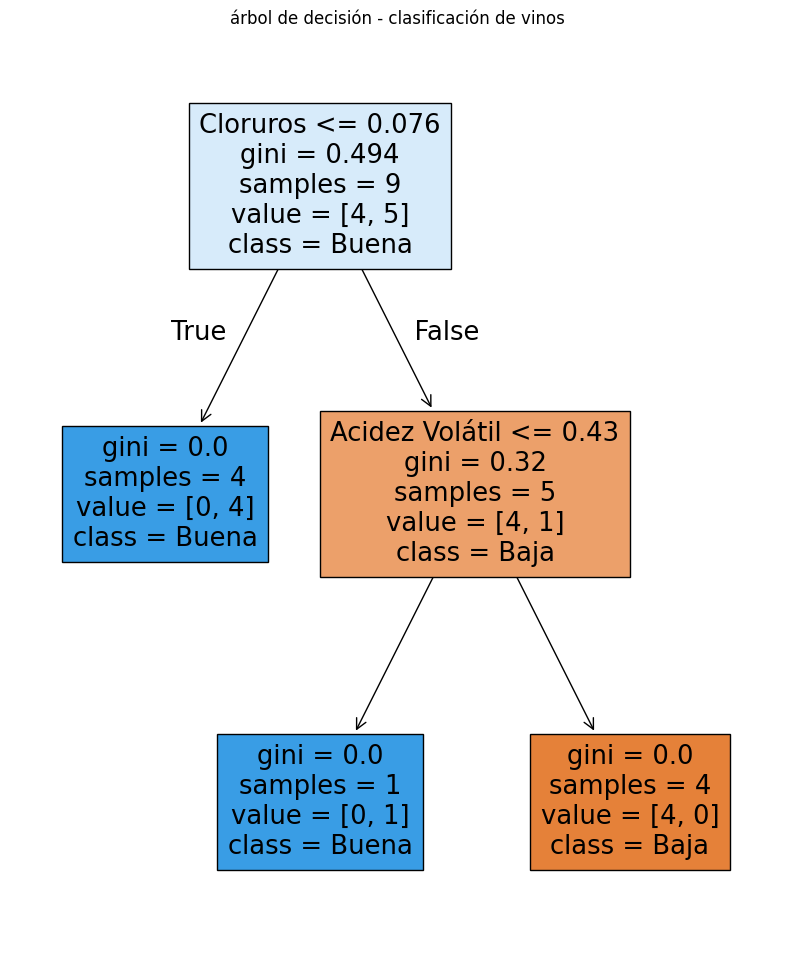


predicción para el vino nuevo:
Baja


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# clasificación multiclase / binaria con datos reales

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# cargar los datos
from google.colab import files

archivo = files.upload()

nombre_archivo = list(archivo.keys())[0]
df = pd.read_excel(nombre_archivo)

print("primeras 5 filas:")
print(df.head())

# revisar los datos
print("\ninformación del dataset:")
df.info()

print("\nvalores nulos:")
print(df.isnull().sum())

# Definir la columna objetivo real de tu Excel
columna_objetivo = 'Categoría_Calidad (Baja/Buena)'

print("\ncantidad de datos por categoría de vino:")
print(df[columna_objetivo].value_counts())

# separar variables
# X = características fisicoquímicas del vino
X = df[
    [
        "Acidez Fija",
        "Acidez Volátil",
        "Ácido Cítrico",
        "Azúcar Residual",
        "Cloruros",
        "Dióxido de Azufre Libre",
        "pH",
        "Sulfatos",
        "Alcohol"
    ]
]

# y = variable que queremos predecir
y = df[columna_objetivo]

print("\nvariables de entrada (X):")
print(X.head())

print("\nvariable objetivo (y):")
print(y.head())

# dividir datos en entrenamiento y prueba
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\ndatos de entrenamiento:", len(X_entrenamiento))
print("datos de prueba:", len(X_prueba))

# crear el modelo
modelo = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# entrenar el modelo
modelo.fit(X_entrenamiento, y_entrenamiento)

print("\nmodelo entrenado correctamente.")

# realizar predicciones
predicciones = modelo.predict(X_prueba)

print("\npredicciones:")
print(predicciones)

# comparar valores reales vs predicciones
resultado = pd.DataFrame({
    "Real": y_prueba.values,
    "Predicho": predicciones
})

print("\ncomparación entre valores reales y predichos:")
print(resultado)

# calcular accuracy
accuracy = accuracy_score(y_prueba, predicciones)

print("\naccuracy:")
print(accuracy)

# reporte de clasificación
print("\nreporte de clasificación:")
print(classification_report(y_prueba, predicciones))

# mostrar el árbol de decisión
plt.figure(figsize=(10, 12))

plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=[str(clase) for clase in modelo.classes_],
    filled=True
)

plt.title("árbol de decisión - clasificación de vinos")
plt.show()

# probar con un vino nuevo (9 características fisicoquímicas)
vino_nuevo = [[
    7.4,   # Acidez Fija
    0.70,  # Acidez Volátil
    0.00,  # Ácido Cítrico
    1.9,   # Azúcar Residual
    0.076, # Cloruros
    11,    # Dióxido de Azufre Libre
    3.51,  # pH
    0.56,  # Sulfatos
    9.4    # Alcohol
]]

prediccion = modelo.predict(vino_nuevo)

print("\npredicción para el vino nuevo:")
print(prediccion[0])

Seleccione el archivo de Excel:


Saving datos_partidos_futbol_200.xlsx to datos_partidos_futbol_200.xlsx

--- Primeras 5 filas del dataset ---
      Clima Temperatura Humedad  Viento Juega_Partido
0  Lluvioso        Baja  Normal  Fuerte            No
1   Nublado        Baja  Normal   Debil            Sí
2  Lluvioso        Baja    Alta   Debil            Sí
3  Lluvioso        Alta  Normal   Debil            No
4  Lluvioso        Alta    Alta   Debil            Sí

--- Distribución de clases (Juega_Partido) ---
Juega_Partido
Sí    116
No     84
Name: count, dtype: int64

Datos de entrenamiento: 160
Datos de prueba: 40

Modelo entrenado correctamente.

Exactitud (Accuracy): 85.0%

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

          No       0.92      0.71      0.80        17
          Sí       0.81      0.96      0.88        23

    accuracy                           0.85        40
   macro avg       0.87      0.83      0.84        40
weighted avg       0.86      0.85      0.

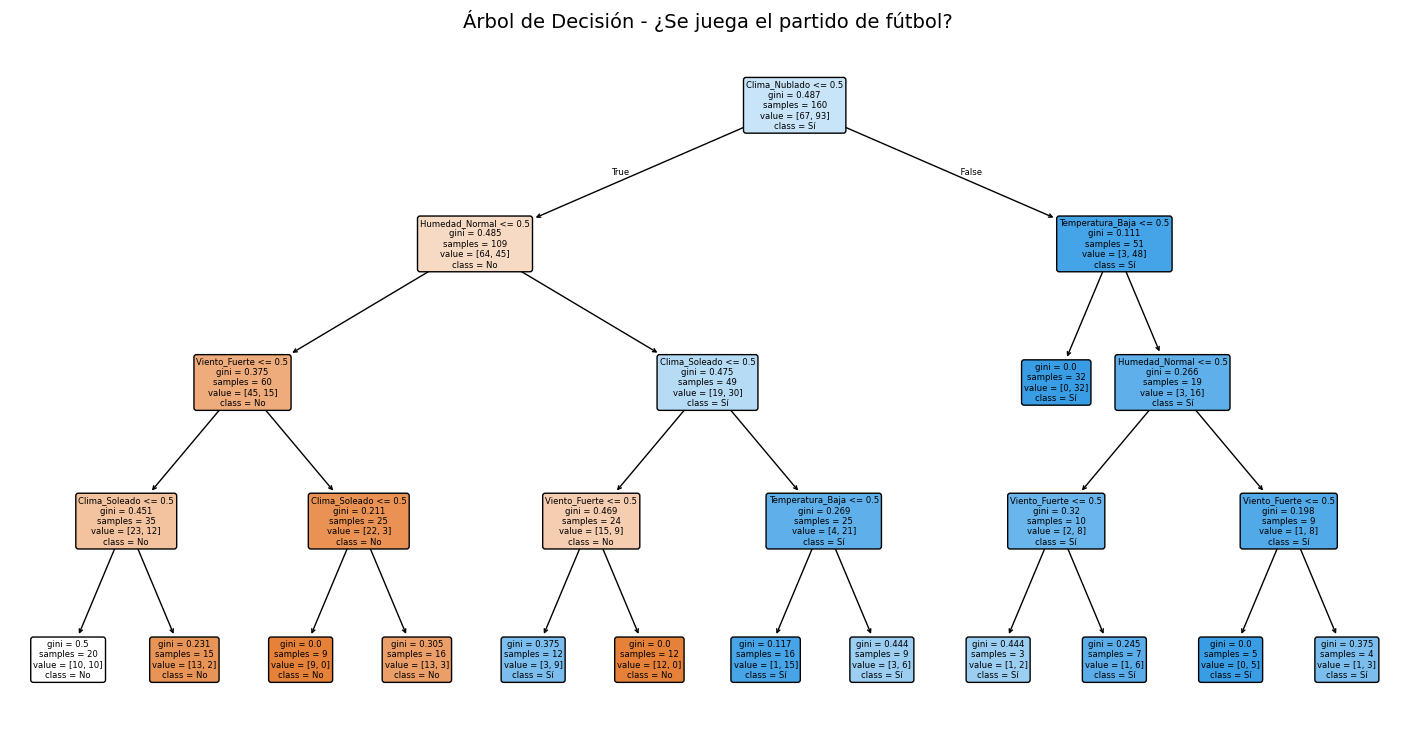


Predicción para el caso nuevo: ¿Se juega el partido? -> Sí


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

from google.colab import files

# 1. Cargar el archivo Excel
print("Seleccione el archivo de Excel:")
subido = files.upload()

nombre_archivo = list(subido.keys())[0]
df = pd.read_excel(nombre_archivo, sheet_name=0)

# Eliminar columna de ID si existe
if "ID_Registro" in df.columns:
    df = df.drop(columns=["ID_Registro"])

print("\n--- Primeras 5 filas del dataset ---")
print(df.head())

print("\n--- Distribución de clases (Juega_Partido) ---")
print(df["Juega_Partido"].value_counts())

# 2. Convertir variables de texto a numéricas (One-Hot Encoding)
df_procesado = pd.get_dummies(
    df,
    columns=["Clima", "Temperatura", "Humedad", "Viento"],
    drop_first=True
)

# 3. Separar entradas (X) y objetivo (y)
X = df_procesado.drop(columns=["Juega_Partido"])
y = df_procesado["Juega_Partido"]

# 4. Dividir en conjuntos de entrenamiento (80%) y prueba (20%)
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nDatos de entrenamiento: {len(X_entrenamiento)}")
print(f"Datos de prueba: {len(X_prueba)}")

# 5. Crear y entrenar el modelo de Árbol de Decisión
modelo = DecisionTreeClassifier(
    max_depth=4,
    criterion="gini",
    random_state=42
)

modelo.fit(X_entrenamiento, y_entrenamiento)
print("\nModelo entrenado correctamente.")

# 6. Evaluar el modelo
predicciones = modelo.predict(X_prueba)

accuracy = accuracy_score(y_prueba, predicciones)
print(f"\nExactitud (Accuracy): {round(accuracy * 100, 2)}%")

print("\n--- Reporte de Clasificación ---")
print(classification_report(y_prueba, predicciones))

# 7. Graficar el Árbol de Decisión
plt.figure(figsize=(18, 9))
plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=[str(clase) for clase in modelo.classes_],
    filled=True,
    rounded=True
)
plt.title("Árbol de Decisión - ¿Se juega el partido de fútbol?", fontsize=14)
plt.show()

# 8. Probar con un caso nuevo
# Ejemplo: Clima = Soleado, Temperatura = Media, Humedad = Normal, Viento = Debil
caso_nuevo = pd.DataFrame([{
    'Clima_Nublado': False,
    'Clima_Soleado': True,
    'Temperatura_Baja': False,
    'Temperatura_Media': True,
    'Humedad_Normal': True,
    'Viento_Fuerte': False
}])

# Asegurar que las columnas del caso nuevo coincidan exactamente con X
caso_nuevo = caso_nuevo.reindex(columns=X.columns, fill_value=False)

prediccion_nueva = modelo.predict(caso_nuevo)
print(f"\nPredicción para el caso nuevo: ¿Se juega el partido? -> {prediccion_nueva[0]}")

seleccione el archivo: 


Saving datos_fraude_tarjetas_200.xlsx to datos_fraude_tarjetas_200.xlsx

primeras 5 filas del dataset:
   ID_Transaccion    Monto  Hora  Distancia_km  Intentos Internacional  \
0               1   135.65     2        768.96         3            No   
1               2  1407.99    10        852.09         2            No   
2               3  1755.72     5          1.67         4            No   
3               4   792.07    14        102.04         1            No   
4               5  2266.99     9        911.15         5            Sí   

  Dispositivo_Nuevo Fraude  
0                No     No  
1                Sí     No  
2                Sí     Sí  
3                No     No  
4                Sí     Sí  

distribución de clases (fraude):
Fraude
No    122
Sí     78
Name: count, dtype: int64

datos de entrenamiento: 160
datos de prueba: 40

--- regresión logística ---
accuracy: 60.0 %

reporte de clasificación:
               precision    recall  f1-score   support

          No 

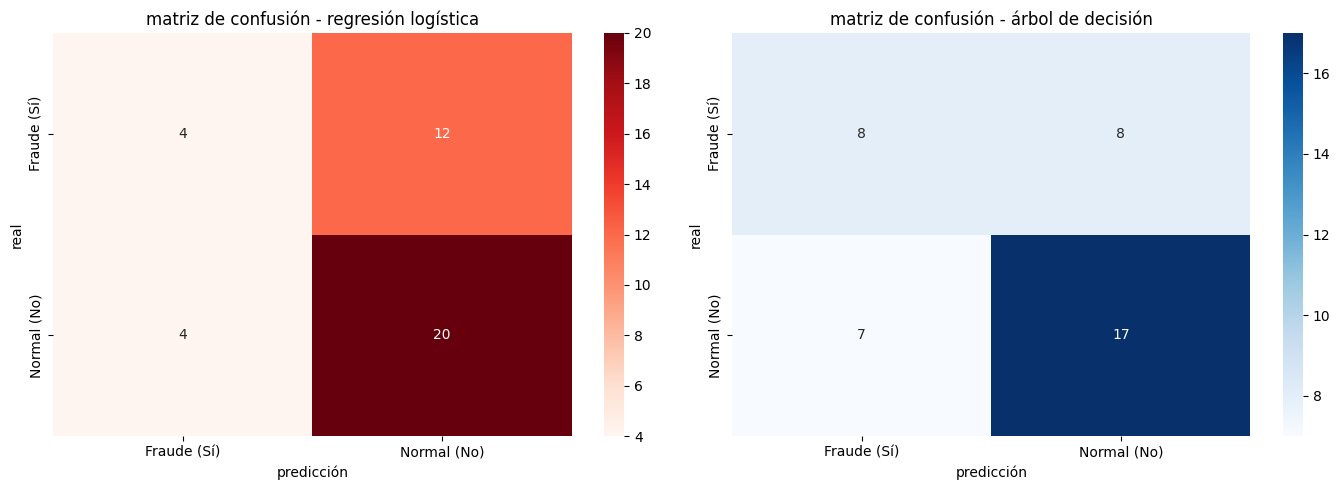

In [ ]:
# detector de fraude con tarjeta (matriz de confusión y métricas)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)
from google.colab import files

# cargar el archivo de excel
print("seleccione el archivo: ")
subido = files.upload()

nombre_archivo = list(subido.keys())[0]
df = pd.read_excel(nombre_archivo, sheet_name="Transacciones")

print("\nprimeras 5 filas del dataset:")
print(df.head())

print("\ndistribución de clases (fraude):")
print(df["Fraude"].value_counts())

# limpieza y preparación de variables
if "ID_Transaccion" in df.columns:
    df = df.drop(columns=["ID_Transaccion"])

# convertir variables categóricas a numéricas usando one-hot encoding
df_procesado = pd.get_dummies(
    df,
    columns=["Internacional", "Dispositivo_Nuevo"],
    drop_first=True
)

# separar entradas (x) y objetivo (y)
X = df_procesado.drop(columns=["Fraude"])
y = df_procesado["Fraude"]

# dividir datos en entrenamiento  con estratificación
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\ndatos de entrenamiento: {len(X_entrenamiento)}")
print(f"datos de prueba: {len(X_prueba)}")

# modelo 1: regresión logística
modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_entrenamiento, y_entrenamiento)
pred_log = modelo_log.predict(X_prueba)

print("\n--- regresión logística ---")
print("accuracy:", round(accuracy_score(y_prueba, pred_log) * 100, 2), "%")
print("\nreporte de clasificación:\n", classification_report(y_prueba, pred_log))

# modelo 2: árbol de decisión
modelo_arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_arbol.fit(X_entrenamiento, y_entrenamiento)
pred_arbol = modelo_arbol.predict(X_prueba)

print("\n--- árbol de decisión ---")
print("accuracy:", round(accuracy_score(y_prueba, pred_arbol) * 100, 2), "%")
print("\nreporte de clasificación:\n", classification_report(y_prueba, pred_arbol))

# matrices de confusión visuales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# matriz regresión logística
cm_log = confusion_matrix(y_prueba, pred_log, labels=["Sí", "No"])
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Reds", ax=axes[0],
            xticklabels=["Fraude (Sí)", "Normal (No)"],
            yticklabels=["Fraude (Sí)", "Normal (No)"])
axes[0].set_title("matriz de confusión - regresión logística")
axes[0].set_ylabel("real")
axes[0].set_xlabel("predicción")

# matriz árbol de decisión
cm_arbol = confusion_matrix(y_prueba, pred_arbol, labels=["Sí", "No"])
sns.heatmap(cm_arbol, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Fraude (Sí)", "Normal (No)"],
            yticklabels=["Fraude (Sí)", "Normal (No)"])
axes[1].set_title("matriz de confusión - árbol de decisión")
axes[1].set_ylabel("real")
axes[1].set_xlabel("predicción")

plt.tight_layout()
plt.show()